# Project 2 - computational part

### Group members

Tereza Bílková (7137257), Bela F. Brunner (8002193), Niels Epema (2927578), Adam Zich (0074187)

In [2]:
# Imports

import numpy as np
import matplotlib.pyplot as plt

In [36]:
# Initial constants

T = 0.1 # Oscilation period (s)
omega = 2 * np.pi / T # Angular frequency (rad/s)
rho = 1000 # Fluid density (kg/m^3)
g = 9.81 # Gravitational acceleration (m/s^2)
mu = 1 # Dynamic viscosity (N*s/m^2)
nu = mu / rho # Kinematic viscosity (m^2/s)
U0 = 100 # horizontal plate velocity amplitude (m/s)

In [4]:
# Generate z-column array

def generate_z_column(z_min, z_max, dz):
    num_points = int((z_max - z_min) / dz) + 1
    return np.linspace(z_min, z_max, num_points)

In [5]:
# Velocity function of the horizontal plate at z = 0

def plate_velocity(t):
    return U0 * np.sin(omega * t)

## a) Geometry

Determine appropriate upper boudnary H

## b)

Based on the results from the analytic part a good value for dz is __TODO__

In [26]:
# Compute diffusion

# Function to approximate the second vertical derivative using central difference
def second_vertical_derivative(u, dz):
    return (u[2:] + u[:-2] - 2 * u[1:-1]) / dz**2

# Function to compute the right-hand side of the diffusion equation
def F_RHS(u, dz):
    return nu * second_vertical_derivative(u, dz)

# Function to compute the diffusion equation using an explicit time-stepping method
# Note: dt must satify: dt < dx^2 / (2 * nu)
def diffusion_equation(u, dz, dt, t):
    return np.append(np.append([plate_velocity(t)], u[1:-1] + dt * F_RHS(u, dz)), 0)

# Function to iteratively apply the diffusion equation for a given number of time steps
def iterative_diffusion(u, dz, dt, N_t):
    for t in range(1, N_t):
        u.append(diffusion_equation(u[t-1], dz, dt, t * dt))
    return u

## c)

Based on the results above a good value for dt given the period T is __TODO__. Additionally, the numnber of time steps that should be chosen is N<sub>t</sub> = __TODO__.

## d)

In [7]:
# Plotting functions

def contour_plot(z, t, u):
    plt.figure(figsize=(10, 6))
    plt.contourf(t, z, u, levels=50, cmap='viridis')
    plt.colorbar(label='Velocity (m/s)')
    plt.xlabel('Time (s)')
    plt.ylabel('Height (m)')
    plt.title('Velocity Contour Plot')
    plt.show()

def line_plot(x, u, representative_points, x_label, rep_point_name):
    plt.figure(figsize=(10, 6))
    plt.plot(u[representative_points], x, label=f't={t:.2f}s')
    plt.xlabel(x_label)
    plt.ylabel('Velocity (m/s)')
    plt.title(f'Velocity profiles at Representative {rep_point_name} points')
    plt.legend()
    plt.grid()
    plt.show()

### d) plots

#### 1) Contour plot of u(t, z)

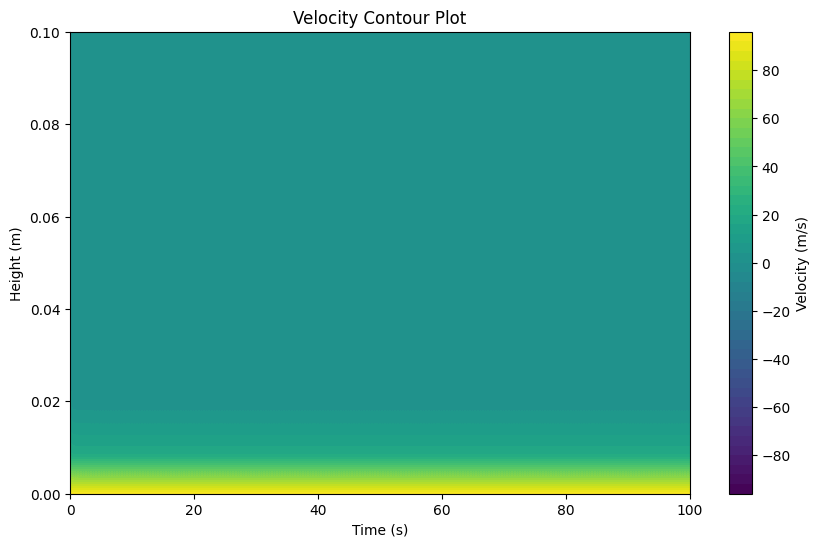

In [40]:
# Plot 1)
dz = 0.01
dt = 0.01
t_max = 100
N_t = int(t_max / dt) + 1
t = np.linspace(0, N_t * dt, N_t)
z = generate_z_column(0, 0.1, dz)
u = np.append([plate_velocity(0)], np.zeros((1, len(z) - 1)))
u = iterative_diffusion([u], dz, dt, N_t)
u = np.transpose(u)
contour_plot(z, t, u)

### d) - subquestions

It takes __TODO__ periods before the effect of starting up is gone.

Once the start-up effect is gone our numerical result compares __TODO__ compared with the analytical reuslt.

## e)

In [ ]:
# New constants

T_2 = T/2 # Oscilation period (s)
omega_2 = 2 * np.pi / T_2 # Angular frequency (rad/s)

In [ ]:
# New velocity function of the horizontal plate at z = 0

def plate_velocity_2(t):
    positive = -2 * (np.floor(t / T_2) % 2)
    return U0 * (1 + positive)

In [ ]:
# Generate plots for new period and velocity function